<a href="https://colab.research.google.com/github/Srimathi-j/medicine-insurance-cost-prediction/blob/main/medicine_insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
#install the required libraries
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost


In [11]:
#import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [12]:
#load dataset
df = pd.read_csv("insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [13]:
#encode categorical features
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])      # male = 1, female = 0
df['smoker'] = le.fit_transform(df['smoker']) # yes = 1, no = 0
df['region'] = le.fit_transform(df['region']) # Converts to numeric labels
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [14]:
#feature scaling
scaler = StandardScaler()
df[['age', 'bmi', 'children']] = scaler.fit_transform(df[['age', 'bmi', 'children']])
df.head()


,age,sex,bmi,children,smoker,region,charges
0,-1.438764,0,-0.453320,-0.908614,1,3,16884.92400
1,-1.509965,1,0.509621,-0.078767,0,2,1725.55230
2,-0.797954,1,0.383307,1.580926,0,2,4449.46200
3,-0.441948,1,-1.305531,-0.908614,0,1,21984.47061
4,-0.513149,1,-0.292556,-0.908614,0,1,3866.85520


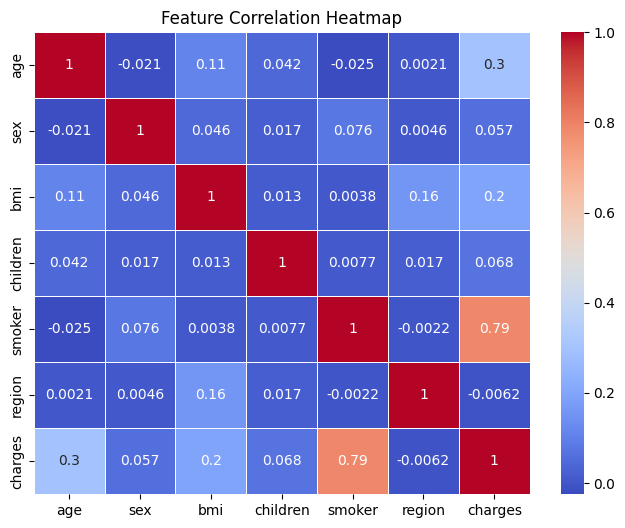

In [15]:
#feature selection
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


In [16]:
#test-train split
X = df.drop(columns=['charges'])  # Features
y = df['charges']                 # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (1070, 6)
Testing set size: (268, 6)


In [17]:
#linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
print(f"Linear Regression R² Score: {r2_score(y_test, y_pred_lr)}")


Linear Regression R² Score: 0.7833463107364538


In [18]:
#random forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(f"Random Forest R² Score: {r2_score(y_test, y_pred_rf)}")


Random Forest R² Score: 0.8658416529065179


In [19]:
#xgboost model
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
print(f"XGBoost R² Score: {r2_score(y_test, y_pred_xgb)}")


XGBoost R² Score: 0.8752215807607839


In [20]:
#evaluate model performance
models = {'Linear Regression': y_pred_lr, 'Random Forest': y_pred_rf, 'XGBoost': y_pred_xgb}

for name, y_pred in models.items():
    print(f"\n{name}:")
    print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
    print(f"MSE: {mean_squared_error(y_test, y_pred)}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
    print(f"R² Score: {r2_score(y_test, y_pred)}")



Linear Regression:
MAE: 4186.5088983664355
MSE: 33635210.43117843
RMSE: 5799.587091438358
R² Score: 0.7833463107364538

Random Forest:
MAE: 2514.888056629137
MSE: 20827913.205296144
RMSE: 4563.760861975148
R² Score: 0.8658416529065179

XGBoost:
MAE: 2396.182613875481
MSE: 19371691.30443699
RMSE: 4401.328356807407
R² Score: 0.8752215807607839


In [21]:
#hyperparameter tuning for xgboost
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

grid_search = GridSearchCV(XGBRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)
print(f"Tuned XGBoost R² Score: {r2_score(y_test, y_pred_best)}")


Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Tuned XGBoost R² Score: 0.8844852893828216


In [22]:
#precticting insurance cost for new user
sample_input = np.array([[45, 1, 28.5, 2, 1, 2]])  # Example input

# Scale input
sample_input[:, :3] = scaler.transform(sample_input[:, :3])

# Predict using best model
predicted_cost = best_model.predict(sample_input)
print("Predicted Insurance Cost:", predicted_cost[0])


Predicted Insurance Cost: 45528.266


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


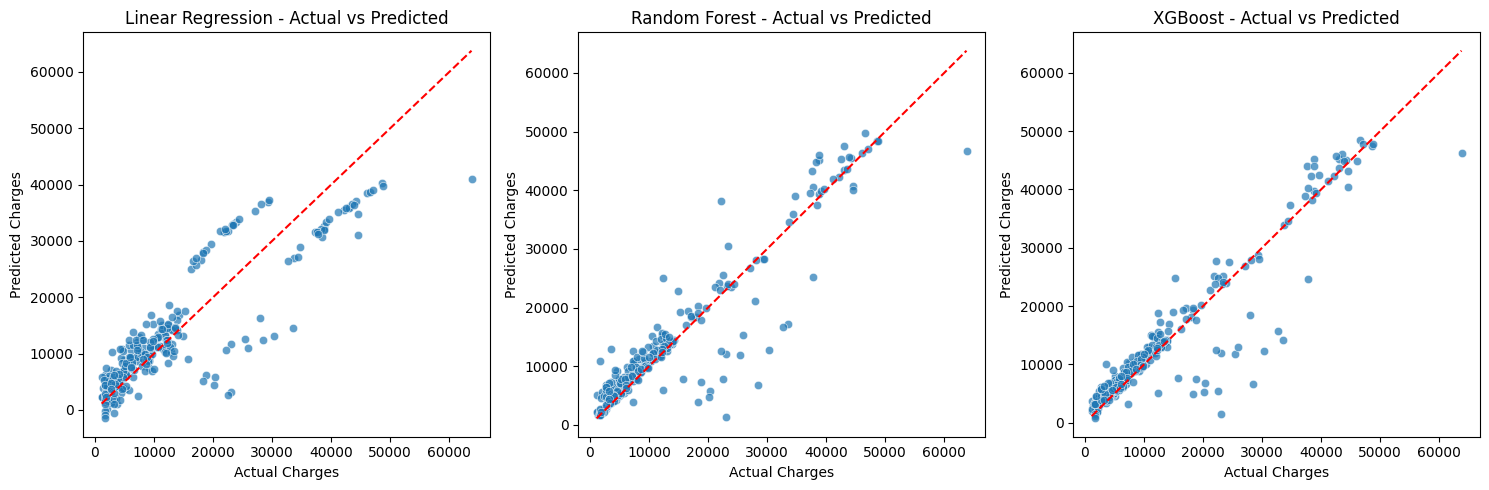

In [23]:
#data visualisation
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15,5))

models = {
    'Linear Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

for i, (name, y_pred) in enumerate(models.items(), 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', linestyle='dashed')
    plt.xlabel("Actual Charges")
    plt.ylabel("Predicted Charges")
    plt.title(f"{name} - Actual vs Predicted")

plt.tight_layout()
plt.show()


